# Merlin UK Opportunity Scoring

This notebook creates the Layer 2 opportunity scoring and attraction alignment output for the Merlin UK geographic customer opportunity prototype.

It uses:

- Layer 1 MSOA customer segments from `notebooks/3_clustering.ipynb`
- Public demographic features carried through the segment output
- Curated Merlin attraction metadata from `data/processed/merlin_attraction_data.csv`

## 1. Setup

Define file paths, scoring weights, and shared helper functions.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", None)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DATA_OUTPUT_DIR = PROJECT_ROOT / "data" / "output"
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEGMENT_INPUT_PATH = DATA_PROCESSED_DIR / "msoa_layer_1_customer_segments.csv"
SEGMENT_PROFILE_PATH = DATA_PROCESSED_DIR / "msoa_layer_1_segment_profile_summary.csv"
ATTRACTION_INPUT_PATH = DATA_PROCESSED_DIR / "merlin_attraction_data.csv"

OPPORTUNITY_OUTPUT_PATH = DATA_OUTPUT_DIR / "msoa_layer_2_opportunity_scores.csv"
TOP_OPPORTUNITY_OUTPUT_PATH = DATA_OUTPUT_DIR / "msoa_layer_2_top_opportunity_msoas.csv"
KEY_RECOMMENDATION_OUTPUT_PATH = DATA_OUTPUT_DIR / "merlin_key_recommendation_output.csv"

SCORING_WEIGHTS = {
    "market_size_score": 0.40,
    "segment_priority_score": 0.30,
    "recommended_attraction_alignment_score": 0.30,
}
assert abs(sum(SCORING_WEIGHTS.values()) - 1.0) < 1e-9

PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9"]

ANNUAL_PASS_DISTANCE_KM = 45
CLUSTER_MARKETING_DISTANCE_KM = 45
CLUSTER_MARKETING_MIN_ATTRACTIONS = 2
SHORT_BREAK_MIN_DISTANCE_KM = 60
SHORT_BREAK_MAX_DISTANCE_KM = 180
REVENUE_PER_VISITOR_ASSUMPTION_GBP = 33.0
ILLUSTRATIVE_PENETRATION_RATE = 0.01


def percentile_score(series, ascending=True):
    return series.rank(pct=True, ascending=ascending, method="average").astype(float)


def clipped_01(series):
    return pd.Series(series).clip(lower=0, upper=1).astype(float)


def haversine_km(lat1, lon1, lat2, lon2):
    radius_km = 6371.0088
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * radius_km * np.arcsin(np.sqrt(a))

## 2. Load Inputs and QA

Load the Layer 1 segment output and Merlin attraction data. The MSOA file already includes segment labels and the raw count variables needed for opportunity scoring.

In [2]:
msoa = pd.read_csv(SEGMENT_INPUT_PATH, dtype={"geo_code": str})
segment_profile = pd.read_csv(SEGMENT_PROFILE_PATH)
attractions = pd.read_csv(ATTRACTION_INPUT_PATH, encoding="utf-8-sig")

print(f"MSOAs: {msoa.shape[0]:,} rows x {msoa.shape[1]:,} columns")
print(f"Attractions: {attractions.shape[0]:,} rows x {attractions.shape[1]:,} columns")

display(msoa.head())
display(attractions)

MSOAs: 7,264 rows x 28 columns
Attractions: 20 rows x 11 columns


,geo_code,geo_name,country,latitude,longitude,segment_id,segment_label,total_population,children_count_0_14,young_adult_count_15_24,core_family_adult_count_25_44,midlife_adult_count_45_64,older_adult_count_65_plus,total_households,households_with_dependent_children,households_deprived,households_not_deprived,households_no_car_or_van,households_with_car_or_van,residents_social_grade_ab_c1,children_share_0_14,young_adult_share_15_24,core_family_adult_share_25_44,midlife_adult_share_45_64,older_adult_share_65_plus,car_access_household_share,population_density_per_sq_km,ab_c1_social_grade_share
0,E02000001,City of London 001,England,51.51562,-0.093490,0,Dense Urban Professional Markets,8580,546,1181,3488,2159,1206,4916,431,1977,2937,3793,1120,5950,0.063636,0.137646,0.406527,0.251632,0.140559,0.227967,2975.0,0.840514
1,E02000002,Barking and Dagenham 001,England,51.58652,0.138756,2,Balanced Regional Family Markets,8286,2172,1028,2426,1731,929,2871,1350,1916,954,914,1956,2971,0.262129,0.124065,0.292783,0.208907,0.112117,0.681533,3831.0,0.410756
2,E02000003,Barking and Dagenham 002,England,51.57606,0.138149,2,Balanced Regional Family Markets,11539,2560,1451,3653,2604,1271,3931,1660,2281,1649,1156,2774,4756,0.221856,0.125747,0.316579,0.225669,0.110148,0.705852,5389.7,0.473847
3,E02000004,Barking and Dagenham 003,England,51.55639,0.176828,4,Mainstream Affluent Suburban Markets,6638,1238,815,1919,1667,999,2309,835,1295,1014,544,1765,2739,0.186502,0.122778,0.289093,0.251130,0.150497,0.764400,2663.6,0.508069
4,E02000005,Barking and Dagenham 004,England,51.56069,0.144267,2,Balanced Regional Family Markets,11082,2935,1355,3503,2406,883,3627,1804,2086,1544,1016,2612,4628,0.264844,0.122270,0.316098,0.217109,0.079679,0.719956,9327.5,0.461278


,attraction_name_official,brand_official,business_division_official,city_official,postcode_official,latitude,longitude,experience_category_inferred,indoor_outdoor_inferred,target_age_group_inferred,family_friendly_inferred
0,Alton Towers Resort,Alton Towers,Resort Theme Parks,Alton,ST10 4DB,52.985926,-1.887592,Thrill Theme Park,Mixed,children_0_14|young_adults_15_24|core_family_adults_25_44,Yes
1,Thorpe Park,Thorpe Park,Resort Theme Parks,Chertsey,KT16 8PN,51.405100,-0.532991,Thrill Theme Park,Outdoor,young_adults_15_24|core_family_adults_25_44,Yes
2,Chessington World of Adventures Resort,Chessington,Resort Theme Parks,Chessington,KT9 2NE,51.348502,-0.321584,Family Theme Park,Mixed,children_0_14|core_family_adults_25_44,Yes
3,LEGOLAND Windsor Resort,LEGOLAND,Resort Theme Parks,Windsor,SL4 4AY,51.463834,-0.652602,Family Theme Park,Outdoor,children_0_14|core_family_adults_25_44,Yes
4,Warwick Castle,Warwick Castle,Gateway Attractions,Warwick,CV34 6AU,52.279500,-1.584900,Heritage Attraction,Mixed,children_0_14|core_family_adults_25_44|midlife_adults_45_64,Yes
5,London Eye,London Eye,Gateway Attractions,London,SE1 7PB,51.503186,-0.122094,Urban Icon Attraction,Outdoor,all_age_groups,Yes
6,Madame Tussauds London,Madame Tussauds,Gateway Attractions,London,NW1 5LR,51.523005,-0.156988,Urban Icon Attraction,Indoor,all_age_groups,Yes
7,London Dungeon,The Dungeons,Gateway Attractions,London,SE1 7PB,51.502512,-0.121338,Young Adult Immersive,Indoor,young_adults_15_24|core_family_adults_25_44,No
8,Shrek's Adventure! London,Shrek's Adventure!,Gateway Attractions,London,SE1 7PB,51.501882,-0.121948,Family Discovery Attraction,Indoor,children_0_14|core_family_adults_25_44,Yes
9,Cadbury World,Cadbury World,Gateway Attractions,Birmingham,B30 1JR,52.428795,-1.934000,Family Discovery Attraction,Indoor,children_0_14|core_family_adults_25_44|midlife_adults_45_64,Yes


### 2.1 Check missing values

In [3]:
required_msoa_columns = [
    "geo_code", "geo_name", "country", "latitude", "longitude", "segment_id", "segment_label",
    "total_population", "children_count_0_14", "young_adult_count_15_24",
    "core_family_adult_count_25_44", "midlife_adult_count_45_64", "older_adult_count_65_plus",
    "total_households", "households_with_dependent_children", "households_deprived",
    "households_no_car_or_van", "households_with_car_or_van", "residents_social_grade_ab_c1",
    "children_share_0_14", "young_adult_share_15_24", "core_family_adult_share_25_44",
    "midlife_adult_share_45_64", "older_adult_share_65_plus", "car_access_household_share",
    "population_density_per_sq_km", "ab_c1_social_grade_share",
]
required_attraction_columns = [
    "attraction_name_official", "brand_official", "business_division_official", "city_official",
    "latitude", "longitude", "experience_category_inferred", "target_age_group_inferred",
    "family_friendly_inferred",
]

missing_msoa_columns = sorted(set(required_msoa_columns) - set(msoa.columns))
missing_attraction_columns = sorted(set(required_attraction_columns) - set(attractions.columns))
assert not missing_msoa_columns, f"Missing MSOA columns: {missing_msoa_columns}"
assert not missing_attraction_columns, f"Missing attraction columns: {missing_attraction_columns}"
assert msoa["geo_code"].is_unique, "Each MSOA should appear once."
assert msoa[["latitude", "longitude"]].notna().all().all(), "MSOA latitude/longitude cannot be missing."
assert attractions[["latitude", "longitude"]].notna().all().all(), "Attraction latitude/longitude cannot be missing."

msoa[required_msoa_columns].isna().sum().sort_values(ascending=False).head(10)

geo_code                              0
households_with_dependent_children    0
population_density_per_sq_km          0
car_access_household_share            0
older_adult_share_65_plus             0
midlife_adult_share_45_64             0
core_family_adult_share_25_44         0
young_adult_share_15_24               0
children_share_0_14                   0
residents_social_grade_ab_c1          0
dtype: int64

## 3. Feature Engineering for Scoring

Only two MSOA-level scores are needed before the attraction recommendation step:

- `market_size_score`: MSOA population percentile. Larger MSOAs score higher because they offer more addressable demand.
- `segment_priority_score`: business judgement from the Layer 1 segment interpretation. Higher-priority segments score higher because they better match Merlin's strategic customer opportunity.

Other demographic variables are still kept in the output for context and later analysis, but they are not converted into separate opportunity-score components here.

In [4]:
scored = msoa.copy()

# Keep these descriptive shares for export and interpretation, but do not use them as separate score components.
scored["family_household_share"] = scored["households_with_dependent_children"] / scored["total_households"]
scored["deprived_household_share"] = scored["households_deprived"] / scored["total_households"]
scored["not_deprived_household_share"] = 1 - scored["deprived_household_share"]

scored["market_size_score"] = percentile_score(scored["total_population"])

SEGMENT_PRIORITY = {
    "Mainstream Affluent Suburban Markets": 1.00,
    "Balanced Regional Family Markets": 0.80,
    "Dense Urban Professional Markets": 0.60,
    "Older Rural & Low-Density Markets": 0.40,
    "Student & Young Adult Urban Markets": 0.20,
}
scored["segment_priority_score"] = scored["segment_label"].map(SEGMENT_PRIORITY)
assert scored["segment_priority_score"].notna().all(), "Every segment needs a priority score."

pre_recommendation_score_columns = ["market_size_score", "segment_priority_score"]
scored[pre_recommendation_score_columns].describe().round(3)

,market_size_score,segment_priority_score
count,7264.000,7264.000
mean,0.500,0.750
std,0.289,0.256
min,0.000,0.200
25%,0.250,0.400
50%,0.500,0.800
75%,0.750,1.000
max,1.000,1.000


## 4. Merlin Attraction Distance and Alignment

Distances are straight-line centroid-to-attraction distances. They are suitable for a prototype accessibility signal, but they are not drive times.

### 4.1 Explain the Attraction Alignment Score

The attraction recommendation uses a combined `recommended_attraction_alignment_score`. This score is calculated for every MSOA-attraction pair, then the highest-scoring attraction is selected for that MSOA.

The formula is:

```text
recommended_attraction_alignment_score =
    0.70 * segment_category_fit_score
  + 0.30 * attraction_accessibility
```

The two inputs mean:

- `segment_category_fit_score`: how well the attraction category fits the MSOA's customer segment. This comes from the segment-to-category rule table in section 4.3.
- `attraction_accessibility`: how accessible that specific attraction is from the MSOA centroid. This is calculated from straight-line distance:

```text
attraction_accessibility = exp(-distance_to_that_attraction_km / 75)
```

The 70/30 split means the recommendation is mostly driven by customer/proposition fit, but distance still matters when choosing the most practical attraction. This is not a drive-time model; it is a transparent prototype proxy that should be calibrated with travel-time or catchment data if available.

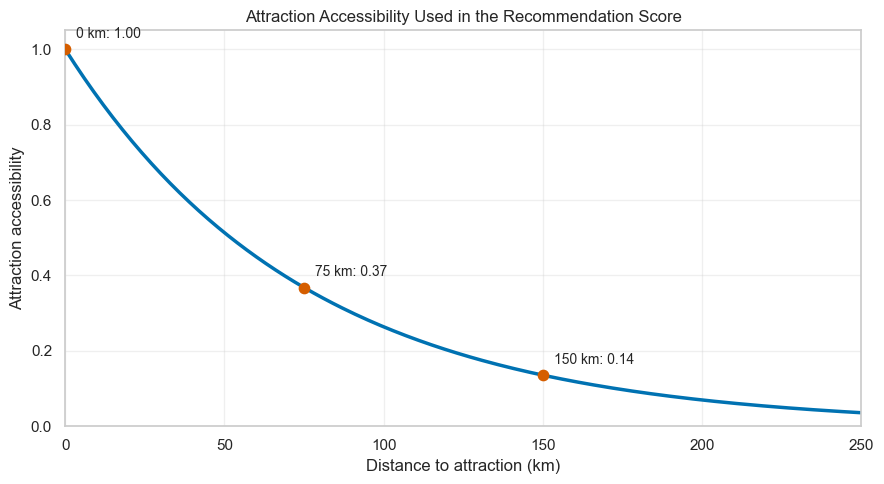

In [5]:
distance_example = pd.DataFrame({"distance_to_attraction_km": np.linspace(0, 250, 251)})
distance_example["attraction_accessibility"] = np.exp(-distance_example["distance_to_attraction_km"] / 75)

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(
    data=distance_example,
    x="distance_to_attraction_km",
    y="attraction_accessibility",
    color="#0072B2",
    linewidth=2.5,
    ax=ax,
)

reference_distances = [0, 75, 150]
for distance in reference_distances:
    score = np.exp(-distance / 75)
    ax.scatter(distance, score, color="#D55E00", s=55, zorder=3)
    ax.annotate(
        f"{distance} km: {score:.2f}",
        xy=(distance, score),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
    )

ax.set_title("Attraction Accessibility Used in the Recommendation Score")
ax.set_xlabel("Distance to attraction (km)")
ax.set_ylabel("Attraction accessibility")
ax.set_xlim(0, 250)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 Calculate Nearest Merlin Attraction Distance

Calculate straight-line distances from every MSOA centroid to every Merlin attraction. This creates the distance matrix used later for attraction-specific accessibility. We also keep the nearest Merlin attraction overall as a descriptive field for interpretation.

In [6]:
msoa_lat = scored["latitude"].to_numpy()[:, None]
msoa_lon = scored["longitude"].to_numpy()[:, None]
attr_lat = attractions["latitude"].to_numpy()[None, :]
attr_lon = attractions["longitude"].to_numpy()[None, :]

distance_matrix = haversine_km(msoa_lat, msoa_lon, attr_lat, attr_lon)
nearest_idx = distance_matrix.argmin(axis=1)

scored["nearest_merlin_attraction"] = attractions.iloc[nearest_idx]["attraction_name_official"].to_numpy()
scored["nearest_merlin_brand"] = attractions.iloc[nearest_idx]["brand_official"].to_numpy()
scored["nearest_merlin_category"] = attractions.iloc[nearest_idx]["experience_category_inferred"].to_numpy()
scored["nearest_merlin_distance_km"] = distance_matrix.min(axis=1).round(1)

for division in attractions["business_division_official"].dropna().unique():
    safe_name = division.lower().replace(" ", "_").replace("/", "_")
    cols = attractions["business_division_official"].eq(division).to_numpy()
    scored[f"nearest_{safe_name}_distance_km"] = distance_matrix[:, cols].min(axis=1).round(1)

scored[["geo_name", "segment_label", "nearest_merlin_attraction", "nearest_merlin_distance_km"]].head()

,geo_name,segment_label,nearest_merlin_attraction,nearest_merlin_distance_km
0,City of London 001,Dense Urban Professional Markets,London Eye,2.4
1,Barking and Dagenham 001,Balanced Regional Family Markets,London Dungeon,20.3
2,Barking and Dagenham 002,Balanced Regional Family Markets,London Dungeon,19.7
3,Barking and Dagenham 003,Mainstream Affluent Suburban Markets,London Dungeon,21.5
4,Barking and Dagenham 004,Balanced Regional Family Markets,London Dungeon,19.5


### 4.3 Segment-Based Attraction Fit and Recommendation

This step recommends a specific Merlin attraction for each MSOA using a simple, explainable process. The recommendation is not based on distance alone, and it is not based on demographics alone. It combines the customer segment fit with attraction accessibility.

The process works as follows:

1. **Start with the MSOA segment.** Each MSOA already has a `segment_label` from Layer 1, such as `Mainstream Affluent Suburban Markets`, `Balanced Regional Family Markets`, or `Student & Young Adult Urban Markets`.

2. **Map that segment to Merlin attraction categories.** The table below assigns a `segment_category_fit_score` between each customer segment and each simplified attraction category from `merlin_attraction_data.csv`. A score of `1.00` means the category is a very strong fit for that segment. Lower scores mean the category is still possible, but less central to the segment proposition.

3. **Score every Merlin attraction for that MSOA.** Each attraction inherits the segment/category fit score for its category. For example, if an MSOA is in `Balanced Regional Family Markets`, then attractions in `Family Discovery Attraction` receive a high fit score because that category is a strong family proposition.

4. **Calculate attraction-specific accessibility.** For each MSOA-attraction pair, calculate `attraction_accessibility` from the straight-line distance to that specific attraction using the distance-decay formula in section 4.1.

5. **Combine fit and accessibility.** For each MSOA-attraction pair, calculate `recommended_attraction_alignment_score` using the 70/30 formula in section 4.1.

6. **Pick the highest-scoring attraction.** The attraction with the highest `recommended_attraction_alignment_score` becomes the `recommended_attraction_name` for that MSOA.

The output fields mean:

- `recommended_attraction_name`: the Merlin attraction with the best combined fit and accessibility score.
- `recommended_attraction_category`: the simplified proposition category of that attraction.
- `recommended_attraction_distance_km`: straight-line distance from the MSOA centroid to the recommended attraction.
- `segment_category_fit_score`: the segment/category fit score of the recommended attraction only.
- `recommended_attraction_alignment_score`: the final combined score used to choose the recommended attraction and to feed into the overall opportunity score.

In short: **the segment decides what kind of Merlin proposition fits; distance helps choose the most practical attraction within that proposition.**

In [7]:
SEGMENT_ATTRACTION_CATEGORY_FIT = {
    "Mainstream Affluent Suburban Markets": {
        "Family Theme Park": 1.00,
        "Family Discovery Attraction": 0.95,
        "Thrill Theme Park": 0.80,
        "Heritage Attraction": 0.75,
        "Urban Icon Attraction": 0.65,
        "Young Adult Immersive": 0.50,
    },
    "Balanced Regional Family Markets": {
        "Family Discovery Attraction": 1.00,
        "Family Theme Park": 0.90,
        "Heritage Attraction": 0.75,
        "Thrill Theme Park": 0.65,
        "Urban Icon Attraction": 0.60,
        "Young Adult Immersive": 0.45,
    },
    "Dense Urban Professional Markets": {
        "Urban Icon Attraction": 1.00,
        "Young Adult Immersive": 0.85,
        "Family Discovery Attraction": 0.75,
        "Thrill Theme Park": 0.65,
        "Heritage Attraction": 0.55,
        "Family Theme Park": 0.50,
    },
    "Student & Young Adult Urban Markets": {
        "Young Adult Immersive": 1.00,
        "Thrill Theme Park": 0.90,
        "Urban Icon Attraction": 0.80,
        "Family Discovery Attraction": 0.55,
        "Family Theme Park": 0.45,
        "Heritage Attraction": 0.35,
    },
    "Older Rural & Low-Density Markets": {
        "Heritage Attraction": 1.00,
        "Family Discovery Attraction": 0.80,
        "Family Theme Park": 0.70,
        "Urban Icon Attraction": 0.55,
        "Thrill Theme Park": 0.45,
        "Young Adult Immersive": 0.30,
    },
}

attraction_categories = attractions["experience_category_inferred"].tolist()
category_fit_matrix = np.array(
    [
        [SEGMENT_ATTRACTION_CATEGORY_FIT[segment].get(category, 0.25) for category in attraction_categories]
        for segment in scored["segment_label"]
    ]
)

attraction_accessibility_matrix = np.clip(np.exp(-distance_matrix / 75), 0, 1)
alignment_matrix = np.clip(0.70 * category_fit_matrix + 0.30 * attraction_accessibility_matrix, 0, 1)
best_alignment_idx = alignment_matrix.argmax(axis=1)

scored["segment_category_fit_score"] = category_fit_matrix[np.arange(len(scored)), best_alignment_idx]
scored["recommended_attraction_name"] = attractions.iloc[best_alignment_idx]["attraction_name_official"].to_numpy()
scored["recommended_attraction_brand"] = attractions.iloc[best_alignment_idx]["brand_official"].to_numpy()
scored["recommended_attraction_category"] = attractions.iloc[best_alignment_idx]["experience_category_inferred"].to_numpy()
scored["recommended_attraction_distance_km"] = distance_matrix[np.arange(len(scored)), best_alignment_idx].round(1)
scored["recommended_attraction_alignment_score"] = alignment_matrix.max(axis=1)
scored["recommended_attraction_focus"] = scored["recommended_attraction_brand"] + " - " + scored["recommended_attraction_category"]

segment_category_fit_table = pd.DataFrame(SEGMENT_ATTRACTION_CATEGORY_FIT).T[attractions["experience_category_inferred"].drop_duplicates().sort_values()]
display(segment_category_fit_table)

scored[[
    "geo_name",
    "segment_label",
    "recommended_attraction_name",
    "recommended_attraction_category",
    "recommended_attraction_distance_km",
    "segment_category_fit_score",
    "recommended_attraction_alignment_score",
]].head()

,Family Discovery Attraction,Family Theme Park,Heritage Attraction,Thrill Theme Park,Urban Icon Attraction,Young Adult Immersive
Mainstream Affluent Suburban Markets,0.95,1.00,0.75,0.80,0.65,0.50
Balanced Regional Family Markets,1.00,0.90,0.75,0.65,0.60,0.45
Dense Urban Professional Markets,0.75,0.50,0.55,0.65,1.00,0.85
Student & Young Adult Urban Markets,0.55,0.45,0.35,0.90,0.80,1.00
Older Rural & Low-Density Markets,0.80,0.70,1.00,0.45,0.55,0.30


,geo_name,segment_label,recommended_attraction_name,recommended_attraction_category,recommended_attraction_distance_km,segment_category_fit_score,recommended_attraction_alignment_score
0,City of London 001,Dense Urban Professional Markets,London Eye,Urban Icon Attraction,2.4,1.00,0.990495
1,Barking and Dagenham 001,Balanced Regional Family Markets,Shrek's Adventure! London,Family Discovery Attraction,20.3,1.00,0.928748
2,Barking and Dagenham 002,Balanced Regional Family Markets,Shrek's Adventure! London,Family Discovery Attraction,19.8,1.00,0.930424
3,Barking and Dagenham 003,Mainstream Affluent Suburban Markets,Shrek's Adventure! London,Family Discovery Attraction,21.5,0.95,0.890113
4,Barking and Dagenham 004,Balanced Regional Family Markets,Shrek's Adventure! London,Family Discovery Attraction,19.5,1.00,0.931188


## 5. Overall Opportunity Score

The overall score is intentionally simple and presentation-friendly. It combines three signals:

1. **Market scale**: is the local population large enough to matter?
2. **Customer segment priority**: is this the type of market Merlin wants to prioritise?
3. **Merlin proposition alignment**: is there a relevant and reasonably accessible Merlin attraction proposition for this MSOA?

The formula is:

```text
overall_opportunity_score =
    0.40 * market_size_score
  + 0.30 * segment_priority_score
  + 0.30 * recommended_attraction_alignment_score
```

The result is multiplied by 100 so the final score is easier to read on a 0-100 scale. The weights are judgement-based prototype assumptions and should be calibrated with internal Merlin customer, revenue, catchment, and media-response data if available.

Priorities:
1. Priority 1 - strongest opportunity
2. Priority 2 - strong opportunity
3. Priority 3 - selective opportunity
4. Priority 4 - monitor / niche

### 5.1 Calculate and Review Overall Opportunity Score

In [8]:
score_columns = list(SCORING_WEIGHTS.keys())
scored["overall_opportunity_score"] = 0.0
for column, weight in SCORING_WEIGHTS.items():
    scored["overall_opportunity_score"] += weight * scored[column]

scored["overall_opportunity_score"] = (100 * scored["overall_opportunity_score"]).round(1)
scored["opportunity_rank"] = scored["overall_opportunity_score"].rank(ascending=False, method="first").astype(int)
scored["opportunity_percentile"] = 1 - ((scored["opportunity_rank"] - 1) / (len(scored) - 1))

rank_share = scored["opportunity_rank"] / len(scored)
scored["opportunity_tier"] = np.select(
    [rank_share <= 0.10, rank_share <= 0.30, rank_share <= 0.60],
    ["Priority 1 - strongest opportunity", "Priority 2 - strong opportunity", "Priority 3 - selective opportunity"],
    default="Priority 4 - monitor / niche",
)

scored[["overall_opportunity_score", "opportunity_rank", "opportunity_tier"] + score_columns].describe().round(2)

,overall_opportunity_score,opportunity_rank,market_size_score,segment_priority_score,recommended_attraction_alignment_score
count,7264.00,7264.00,7264.00,7264.00,7264.00
mean,67.54,3632.50,0.50,0.75,0.84
std,15.11,2097.08,0.29,0.26,0.08
min,29.20,1.00,0.00,0.20,0.70
25%,57.20,1816.75,0.25,0.40,0.77
50%,68.10,3632.50,0.50,0.80,0.82
75%,79.60,5448.25,0.75,1.00,0.91
max,97.70,7264.00,1.00,1.00,1.00


### 5.2 Add Activation and Driver Explanations

In [9]:
def key_contributing_driver(row):
    labels = {
        "market_size_score": "large local market",
        "segment_priority_score": "priority customer segment",
        "recommended_attraction_alignment_score": "strong Merlin proposition alignment",
    }
    weighted_contributions = {
        column: row[column] * SCORING_WEIGHTS[column]
        for column in score_columns
    }
    top_component = max(weighted_contributions, key=weighted_contributions.get)
    return labels[top_component]


scored["key_contributing_driver"] = scored.apply(key_contributing_driver, axis=1)
scored["assumptions_flag"] = "Straight-line distance proxy; judgement-based weights; attraction coordinates and simplified categories are maintained in merlin_attraction_data.csv."

scored.sort_values("opportunity_rank").head(10)[[
    "opportunity_rank", "geo_name", "country", "segment_label", "overall_opportunity_score", "opportunity_tier",
    "recommended_attraction_name", "recommended_attraction_distance_km", "key_contributing_driver",
]]

,opportunity_rank,geo_name,country,segment_label,overall_opportunity_score,opportunity_tier,recommended_attraction_name,recommended_attraction_distance_km,key_contributing_driver
3203,1,Bracknell Forest 002,England,Mainstream Affluent Suburban Markets,97.7,Priority 1 - strongest opportunity,LEGOLAND Windsor Resort,8.3,large local market
569,2,Kingston upon Thames 004,England,Mainstream Affluent Suburban Markets,97.6,Priority 1 - strongest opportunity,Chessington World of Adventures Resort,7.8,large local market
6585,3,Epsom and Ewell 010,England,Mainstream Affluent Suburban Markets,97.6,Priority 1 - strongest opportunity,Chessington World of Adventures Resort,5.8,large local market
3298,4,Wokingham 012,England,Mainstream Affluent Suburban Markets,97.4,Priority 1 - strongest opportunity,LEGOLAND Windsor Resort,20.5,large local market
6154,5,Runnymede 007,England,Mainstream Affluent Suburban Markets,97.4,Priority 1 - strongest opportunity,Chessington World of Adventures Resort,12.9,large local market
6628,6,Harrow 033,England,Mainstream Affluent Suburban Markets,97.2,Priority 1 - strongest opportunity,Chessington World of Adventures Resort,27.0,large local market
6668,7,Redbridge 036,England,Mainstream Affluent Suburban Markets,97.2,Priority 1 - strongest opportunity,Shrek's Adventure! London,15.2,large local market
741,8,Richmond upon Thames 004,England,Mainstream Affluent Suburban Markets,97.1,Priority 1 - strongest opportunity,Chessington World of Adventures Resort,13.5,large local market
3529,9,Buckinghamshire 053,England,Mainstream Affluent Suburban Markets,97.0,Priority 1 - strongest opportunity,LEGOLAND Windsor Resort,16.0,large local market
5001,10,Fylde 002,England,Mainstream Affluent Suburban Markets,96.9,Priority 1 - strongest opportunity,SEA LIFE Blackpool,10.8,large local market


### 5.3 Commercial Activation Plays

The opportunity score ranks where Merlin should focus. This step translates that ranking into a simple commercial recommendation that is easier for senior stakeholders to act on.

The rules are intentionally transparent:

- **Annual Pass / Repeat Visit**: high-opportunity MSOAs within 45km of the recommended attraction. The assumption is that closer households can realistically revisit often enough to make an annual pass attractive.
- **Multi-Attraction Cluster Marketing**: high-opportunity MSOAs within 45km of at least two distinct Merlin attractions. This supports cross-sell, bundled messaging, and annual-pass propositions across nearby attractions.
- **Short Break**: high-opportunity family/affluent MSOAs that are 60-180km from the recommended attraction. The assumption is that very local households are less likely to need accommodation, while very distant households are harder to convert.
- **Illustrative Revenue Opportunity**: a conservative scenario, not a forecast. It uses Merlin annual-report revenue per visitor of about GBP33, a 1% illustrative penetration rate, and the opportunity score as a weighting factor.

Formula:

`illustrative_revenue_opportunity_1pct_gbp = total_population * 1% * GBP33 * (overall_opportunity_score / 100)`

This is useful for comparing relative scale across markets, but it should be calibrated with internal ticket yield, visitor penetration, passholder, accommodation, retail, and food-and-beverage data before being used as a financial forecast.

In [10]:
HIGH_OPPORTUNITY_TIERS = [
    "Priority 1 - strongest opportunity",
    "Priority 2 - strong opportunity",
]
RESORT_OR_DESTINATION_CATEGORIES = [
    "Family Theme Park",
    "Thrill Theme Park",
    "Heritage Attraction",
]

PRIORITY_1_TIER = "Priority 1 - strongest opportunity"
scored["priority_1_flag"] = scored["opportunity_tier"].eq(PRIORITY_1_TIER)
scored["priority_1_population"] = np.where(scored["priority_1_flag"], scored["total_population"], 0)

within_cluster_distance = distance_matrix <= CLUSTER_MARKETING_DISTANCE_KM
scored["merlin_attractions_within_45km"] = within_cluster_distance.sum(axis=1).astype(int)

attraction_names = attractions["attraction_name_official"].to_numpy()
scored["merlin_attraction_cluster_names_45km"] = [
    "; ".join(attraction_names[row]) if row.any() else "None within 45km"
    for row in within_cluster_distance
]

high_opportunity_mask = scored["opportunity_tier"].isin(HIGH_OPPORTUNITY_TIERS)
family_affluent_mask = (
    (scored["family_household_share"] >= scored["family_household_share"].median())
    & (scored["ab_c1_social_grade_share"] >= scored["ab_c1_social_grade_share"].median())
)
resort_or_destination_mask = scored["recommended_attraction_category"].isin(RESORT_OR_DESTINATION_CATEGORIES)

scored["annual_pass_repeat_visit_flag"] = (
    high_opportunity_mask
    & (scored["recommended_attraction_distance_km"] <= ANNUAL_PASS_DISTANCE_KM)
)
scored["cluster_marketing_flag"] = (
    high_opportunity_mask
    & (scored["merlin_attractions_within_45km"] >= CLUSTER_MARKETING_MIN_ATTRACTIONS)
)
scored["short_break_opportunity_flag"] = (
    high_opportunity_mask
    & family_affluent_mask
    & resort_or_destination_mask
    & scored["recommended_attraction_distance_km"].between(SHORT_BREAK_MIN_DISTANCE_KM, SHORT_BREAK_MAX_DISTANCE_KM)
)


def recommended_commercial_play(row):
    if row["cluster_marketing_flag"]:
        return "Multi-attraction cluster marketing"
    if row["annual_pass_repeat_visit_flag"]:
        return "Annual pass / repeat visit"
    if row["short_break_opportunity_flag"]:
        return "Short break"
    if row["opportunity_tier"] in HIGH_OPPORTUNITY_TIERS and row["recommended_attraction_distance_km"] <= 90:
        return "Targeted day visit"
    if row["opportunity_tier"] in HIGH_OPPORTUNITY_TIERS:
        return "Destination-led campaign"
    return "Seasonal / tactical activation"


def commercial_play_rationale(row):
    if row["recommended_commercial_play"] == "Multi-attraction cluster marketing":
        return f"High-opportunity MSOA with {row['merlin_attractions_within_45km']} Merlin attractions within 45km."
    if row["recommended_commercial_play"] == "Annual pass / repeat visit":
        return f"High-opportunity MSOA within {ANNUAL_PASS_DISTANCE_KM}km of the recommended attraction."
    if row["recommended_commercial_play"] == "Short break":
        return "High-opportunity family/affluent MSOA at a practical overnight-trip distance."
    if row["recommended_commercial_play"] == "Targeted day visit":
        return "High-opportunity MSOA close enough for a realistic day visit."
    if row["recommended_commercial_play"] == "Destination-led campaign":
        return "High-opportunity MSOA, but distance suggests destination messaging rather than convenience."
    return "Lower-priority MSOA retained for seasonal, niche, or tactical activity."


def recommended_activation(row):
    play = row["recommended_commercial_play"]
    if play == "Multi-attraction cluster marketing":
        return "Promote annual pass, multi-attraction bundles, CRM cross-sell and local cluster campaigns."
    if play == "Annual pass / repeat visit":
        return "Promote annual pass, repeat-visit benefits and in-attraction upsell opportunities."
    if play == "Short break":
        return "Promote short-break packages, overnight stays and family premium occasions."
    if play == "Targeted day visit":
        return "Promote day-trip offers, family tickets and attraction-specific paid media."
    if play == "Destination-led campaign":
        return "Promote destination inspiration and seasonal trip planning rather than convenience."
    return "Use low-weight seasonal or tactical activation only."


scored["recommended_commercial_play"] = scored.apply(recommended_commercial_play, axis=1)
scored["commercial_play_rationale"] = scored.apply(commercial_play_rationale, axis=1)
scored["recommended_activation"] = scored.apply(recommended_activation, axis=1)

# Keep the original output column name, but make it rule-based rather than segment-only.
scored["recommended_product_focus"] = scored["recommended_commercial_play"]

scored["revenue_per_visitor_assumption_gbp"] = REVENUE_PER_VISITOR_ASSUMPTION_GBP
scored["penetration_rate_assumption"] = ILLUSTRATIVE_PENETRATION_RATE
scored["illustrative_revenue_opportunity_1pct_gbp"] = (
    scored["total_population"]
    * ILLUSTRATIVE_PENETRATION_RATE
    * REVENUE_PER_VISITOR_ASSUMPTION_GBP
    * (scored["overall_opportunity_score"] / 100)
).round(0).astype(int)

commercial_play_summary = (
    scored.groupby("recommended_commercial_play", as_index=False)
    .agg(
        msoa_count=("geo_code", "count"),
        priority_1_msoas=("priority_1_flag", "sum"),
        total_population=("total_population", "sum"),
        illustrative_revenue_opportunity_1pct_gbp=("illustrative_revenue_opportunity_1pct_gbp", "sum"),
        mean_opportunity_score=("overall_opportunity_score", "mean"),
    )
    .sort_values(["priority_1_msoas", "illustrative_revenue_opportunity_1pct_gbp"], ascending=[False, False])
)

commercial_play_summary.round(1)

,recommended_commercial_play,msoa_count,priority_1_msoas,total_population,illustrative_revenue_opportunity_1pct_gbp,mean_opportunity_score
2,Multi-attraction cluster marketing,1002,340,9964996,2817308,85.1
5,Targeted day visit,613,204,6224831,1753492,84.9
0,Annual pass / repeat visit,315,111,3038229,858353,85.1
4,Short break,85,41,878224,254415,87.2
1,Destination-led campaign,164,30,1665920,461536,83.6
3,Seasonal / tactical activation,5085,0,37825163,7648314,60.1


## 6. Business Insights and Activation Priorities

This section translates the MSOA-level opportunity output into the points needed for the business insights and activation slide:

- which customer segments create the strongest opportunity
- which local authority areas contain the highest concentration of Priority 1 MSOAs
- which Merlin propositions are most naturally aligned to those areas
- how media and commercial activation should differ by segment and attraction focus

### 6.1 Which Customer Segments Create the Strongest Opportunity?

In [11]:
PRIORITY_1_TIER = "Priority 1 - strongest opportunity"

scored["priority_1_flag"] = scored["opportunity_tier"].eq(PRIORITY_1_TIER)
scored["priority_1_population"] = np.where(scored["priority_1_flag"], scored["total_population"], 0)
scored["area_name"] = scored["geo_name"].str.replace(r"\s+\d+$", "", regex=True)


def mode_or_none(series):
    modes = series.dropna().mode()
    return modes.iat[0] if not modes.empty else "None"


def top_priority_area_examples(group, n=5):
    areas = group.loc[group["priority_1_flag"], "area_name"].value_counts().head(n).index.tolist()
    return ", ".join(areas) if areas else "No Priority 1 MSOAs"

segment_base_summary = (
    scored.groupby(["segment_id", "segment_label"], as_index=False)
    .agg(
        msoa_count=("geo_code", "count"),
        total_population=("total_population", "sum"),
        mean_opportunity_score=("overall_opportunity_score", "mean"),
        median_opportunity_score=("overall_opportunity_score", "median"),
        priority_1_msoas=("priority_1_flag", "sum"),
        priority_1_population=("priority_1_population", "sum"),
        mean_recommended_distance_km=("recommended_attraction_distance_km", "mean"),
        main_recommended_focus=("recommended_attraction_focus", mode_or_none),
    )
)

segment_area_examples = (
    scored.groupby(["segment_id", "segment_label"])
    .apply(top_priority_area_examples)
    .rename("top_priority_1_area_examples")
    .reset_index()
)

segment_opportunity_summary = (
    segment_base_summary.merge(segment_area_examples, on=["segment_id", "segment_label"], how="left")
    .assign(
        priority_1_share=lambda df: df["priority_1_msoas"] / df["msoa_count"],
        population_millions=lambda df: df["total_population"] / 1_000_000,
        priority_1_population_millions=lambda df: df["priority_1_population"] / 1_000_000,
    )
    .sort_values(["priority_1_msoas", "mean_opportunity_score"], ascending=[False, False])
)

segment_display_cols = [
    "segment_label",
    "msoa_count",
    "population_millions",
    "mean_opportunity_score",
    "priority_1_msoas",
    "priority_1_share",
    "priority_1_population_millions",
    "mean_recommended_distance_km",
    "main_recommended_focus",
    "top_priority_1_area_examples",
]

segment_opportunity_summary[segment_display_cols].round(3)

,segment_label,msoa_count,population_millions,mean_opportunity_score,priority_1_msoas,priority_1_share,priority_1_population_millions,mean_recommended_distance_km,main_recommended_focus,top_priority_1_area_examples
4,Mainstream Affluent Suburban Markets,2950,23.861,74.582,516,0.175,5.607,56.696,SEA LIFE - Family Discovery Attraction,"Buckinghamshire, Richmond upon Thames, Central Bedfordshire, Southend-on-Sea, Wokingham"
2,Balanced Regional Family Markets,1693,14.664,73.325,209,0.123,2.524,43.727,SEA LIFE - Family Discovery Attraction,"Birmingham, Manchester, Sandwell, Brent, Barking and Dagenham"
0,Dense Urban Professional Markets,599,5.215,68.984,1,0.002,0.014,35.863,Madame Tussauds - Urban Icon Attraction,Westminster
3,Student & Young Adult Urban Markets,139,1.358,57.959,0,0.000,0.000,107.109,The Dungeons - Young Adult Immersive,No Priority 1 MSOAs
1,Older Rural & Low-Density Markets,1883,14.499,51.566,0,0.000,0.000,123.861,Warwick Castle - Heritage Attraction,No Priority 1 MSOAs


### 6.2 Where Are the Highest-Priority Local Market Clusters?

In [12]:
priority_area_summary = (
    scored.loc[scored["priority_1_flag"]]
    .groupby(["country", "area_name"], as_index=False)
    .agg(
        priority_1_msoas=("geo_code", "count"),
        priority_1_population=("total_population", "sum"),
        mean_opportunity_score=("overall_opportunity_score", "mean"),
        dominant_segment=("segment_label", mode_or_none),
        main_recommended_attraction=("recommended_attraction_name", mode_or_none),
        main_recommended_brand=("recommended_attraction_brand", mode_or_none),
        main_recommended_category=("recommended_attraction_category", mode_or_none),
        mean_recommended_distance_km=("recommended_attraction_distance_km", "mean"),
        strongest_msoa=("geo_name", mode_or_none),
    )
    .assign(priority_1_population_millions=lambda df: df["priority_1_population"] / 1_000_000)
    .sort_values(["priority_1_msoas", "priority_1_population", "mean_opportunity_score"], ascending=[False, False, False])
)

priority_area_summary.head(20).round(2)

,country,area_name,priority_1_msoas,priority_1_population,mean_opportunity_score,dominant_segment,main_recommended_attraction,main_recommended_brand,main_recommended_category,mean_recommended_distance_km,strongest_msoa,priority_1_population_millions
14,England,Birmingham,23,260284,90.78,Balanced Regional Family Markets,SEA LIFE Birmingham,SEA LIFE,Family Discovery Attraction,5.97,Birmingham 005,0.26
109,England,Manchester,13,147902,90.04,Balanced Regional Family Markets,SEA LIFE Manchester,SEA LIFE,Family Discovery Attraction,10.12,Manchester 002,0.15
29,England,Buckinghamshire,13,141949,91.38,Mainstream Affluent Suburban Markets,LEGOLAND Windsor Resort,LEGOLAND,Family Theme Park,31.56,Buckinghamshire 001,0.14
7,England,Barnet,13,138652,90.99,Mainstream Affluent Suburban Markets,Shrek's Adventure! London,Shrek's Adventure!,Family Discovery Attraction,14.25,Barnet 001,0.14
151,England,Sandwell,12,138149,90.68,Balanced Regional Family Markets,SEA LIFE Birmingham,SEA LIFE,Family Discovery Attraction,7.93,Sandwell 010,0.14
139,England,Redbridge,11,144761,93.01,Balanced Regional Family Markets,Shrek's Adventure! London,Shrek's Adventure!,Family Discovery Attraction,15.55,Redbridge 001,0.14
23,England,Brent,11,126652,89.95,Balanced Regional Family Markets,Shrek's Adventure! London,Shrek's Adventure!,Family Discovery Attraction,12.38,Brent 001,0.13
34,England,Central Bedfordshire,11,124668,91.19,Mainstream Affluent Suburban Markets,LEGOLAND Windsor Resort,LEGOLAND,Family Theme Park,62.80,Central Bedfordshire 005,0.12
171,England,Southend-on-Sea,11,120339,89.43,Mainstream Affluent Suburban Markets,Chessington World of Adventures Resort,Chessington,Family Theme Park,72.12,Southend-on-Sea 002,0.12
107,England,Luton,10,119870,89.13,Balanced Regional Family Markets,Shrek's Adventure! London,Shrek's Adventure!,Family Discovery Attraction,48.72,Luton 006,0.12


### 6.3 Which Merlin Attractions and Proposition Types Align Best to the Opportunity?

In [13]:
attraction_focus_summary = (
    scored.groupby(["recommended_attraction_name", "recommended_attraction_brand", "recommended_attraction_category"], as_index=False)
    .agg(
        msoa_count=("geo_code", "count"),
        total_population=("total_population", "sum"),
        mean_opportunity_score=("overall_opportunity_score", "mean"),
        priority_1_msoas=("priority_1_flag", "sum"),
        priority_1_population=("priority_1_population", "sum"),
        mean_recommended_distance_km=("recommended_attraction_distance_km", "mean"),
        top_priority_1_area_examples=("area_name", lambda s: ", ".join(s[scored.loc[s.index, "priority_1_flag"]].value_counts().head(5).index) if scored.loc[s.index, "priority_1_flag"].any() else "No Priority 1 MSOAs"),
    )
    .assign(
        priority_1_share=lambda df: df["priority_1_msoas"] / df["msoa_count"],
        population_millions=lambda df: df["total_population"] / 1_000_000,
        priority_1_population_millions=lambda df: df["priority_1_population"] / 1_000_000,
    )
    .sort_values(["priority_1_msoas", "mean_opportunity_score"], ascending=[False, False])
)

attraction_category_summary = (
    scored.groupby(["recommended_attraction_category"], as_index=False)
    .agg(
        msoa_count=("geo_code", "count"),
        total_population=("total_population", "sum"),
        mean_opportunity_score=("overall_opportunity_score", "mean"),
        priority_1_msoas=("priority_1_flag", "sum"),
        priority_1_population=("priority_1_population", "sum"),
        mean_recommended_distance_km=("recommended_attraction_distance_km", "mean"),
        top_recommended_attractions=("recommended_attraction_name", lambda s: ", ".join(s.value_counts().head(5).index)),
        top_priority_1_area_examples=("area_name", lambda s: ", ".join(s[scored.loc[s.index, "priority_1_flag"]].value_counts().head(5).index) if scored.loc[s.index, "priority_1_flag"].any() else "No Priority 1 MSOAs"),
    )
    .assign(
        priority_1_share=lambda df: df["priority_1_msoas"] / df["msoa_count"],
        population_millions=lambda df: df["total_population"] / 1_000_000,
        priority_1_population_millions=lambda df: df["priority_1_population"] / 1_000_000,
    )
    .sort_values(["priority_1_msoas", "mean_opportunity_score"], ascending=[False, False])
)

print("Attraction-level opportunity summary")
display(attraction_focus_summary.round(3))

print("Category-level strategic roll-up")
display(attraction_category_summary.round(3))

Attraction-level opportunity summary


,recommended_attraction_name,recommended_attraction_brand,recommended_attraction_category,msoa_count,total_population,mean_opportunity_score,priority_1_msoas,priority_1_population,mean_recommended_distance_km,top_priority_1_area_examples,priority_1_share,population_millions,priority_1_population_millions
3,LEGOLAND Windsor Resort,LEGOLAND,Family Theme Park,695,5690284,74.237,137,1509260,88.258,"Buckinghamshire, Central Bedfordshire, Wokingham, Slough, Vale of White Horse",0.197,5.690,1.509
13,SEA LIFE Manchester,SEA LIFE,Family Discovery Attraction,1136,9071929,70.511,115,1269178,39.130,"Manchester, Rochdale, Salford, Sheffield, Bradford",0.101,9.072,1.269
16,Shrek's Adventure! London,Shrek's Adventure!,Family Discovery Attraction,526,4694406,76.833,110,1282458,29.097,"Barnet, Brent, Redbridge, Barking and Dagenham, Havering",0.209,4.694,1.282
2,Chessington World of Adventures Resort,Chessington,Family Theme Park,348,2985755,79.323,96,1033144,40.294,"Richmond upon Thames, Southend-on-Sea, Reigate and Banstead, Tonbridge and Malling, Horsham",0.276,2.986,1.033
7,SEA LIFE Birmingham,SEA LIFE,Family Discovery Attraction,570,4803330,74.740,86,980722,36.551,"Birmingham, Sandwell, Wolverhampton, Leicester, South Derbyshire",0.151,4.803,0.981
1,Cadbury World,Cadbury World,Family Discovery Attraction,245,1949470,71.796,30,346004,43.584,"Warwick, Birmingham, Solihull, Stroud, Tewkesbury",0.122,1.949,0.346
12,SEA LIFE London Aquarium,SEA LIFE,Family Discovery Attraction,225,1931633,72.030,29,337326,24.436,"Hounslow, Bexley, Hillingdon, Croydon, Ealing",0.129,1.932,0.337
11,SEA LIFE Hunstanton,SEA LIFE,Family Discovery Attraction,138,1215355,71.592,28,330524,56.464,"Peterborough, Fenland, East Cambridgeshire, Lincoln, Breckland",0.203,1.215,0.331
15,SEA LIFE Weymouth,SEA LIFE,Family Discovery Attraction,330,2651655,68.804,26,289402,80.594,"Bournemouth, Christchurch and Poole, Torbay, Somerset West and Taunton, Dorset, Vale of Glamorgan",0.079,2.652,0.289
14,SEA LIFE Scarborough,SEA LIFE,Family Discovery Attraction,360,2805925,67.244,26,294529,79.066,"County Durham, Northumberland, Newcastle upon Tyne, Hartlepool, Middlesbrough",0.072,2.806,0.295


Category-level strategic roll-up


,recommended_attraction_category,msoa_count,total_population,mean_opportunity_score,priority_1_msoas,priority_1_population,mean_recommended_distance_km,top_recommended_attractions,top_priority_1_area_examples,priority_1_share,population_millions,priority_1_population_millions
0,Family Discovery Attraction,4041,33231294,71.255,492,5588237,43.781,"SEA LIFE Manchester, SEA LIFE Birmingham, Shrek's Adventure! London, SEA LIFE Scarborough, SEA LIFE Weymouth","Birmingham, Barnet, Manchester, Sandwell, Brent",0.122,33.231,5.588
1,Family Theme Park,1043,8676039,75.934,233,2542404,72.255,"LEGOLAND Windsor Resort, Chessington World of Adventures Resort","Buckinghamshire, Central Bedfordshire, Richmond upon Thames, Southend-on-Sea, Wokingham",0.223,8.676,2.542
4,Urban Icon Attraction,539,4709834,69.585,1,14480,38.182,"Madame Tussauds London, London Eye",Westminster,0.002,4.710,0.014
3,Thrill Theme Park,25,264525,63.504,0,0,42.152,"Alton Towers Resort, Thorpe Park",No Priority 1 MSOAs,0.000,0.265,0.000
5,Young Adult Immersive,135,1271740,58.133,0,0,107.864,"The York Dungeon, London Dungeon",No Priority 1 MSOAs,0.000,1.272,0.000
2,Heritage Attraction,1481,11443931,51.689,0,0,150.174,Warwick Castle,No Priority 1 MSOAs,0.000,11.444,0.000


### 6.4 How Does Opportunity Vary by Segment and Tier?

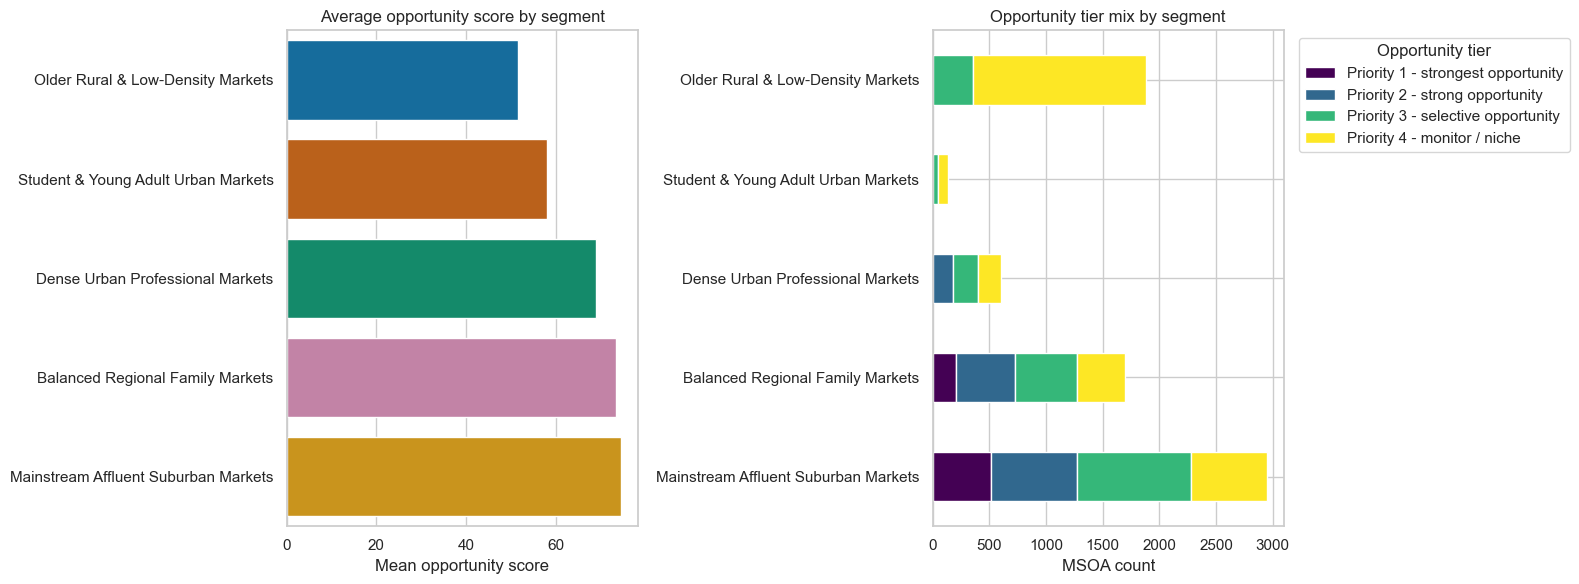

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

segment_plot = segment_opportunity_summary.sort_values("mean_opportunity_score", ascending=True)
segment_palette = dict(zip(segment_plot["segment_label"], PALETTE[: len(segment_plot)]))
sns.barplot(
    data=segment_plot,
    x="mean_opportunity_score",
    y="segment_label",
    hue="segment_label",
    palette=segment_palette,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Average opportunity score by segment")
axes[0].set_xlabel("Mean opportunity score")
axes[0].set_ylabel("")

segment_tier_counts = pd.crosstab(scored["segment_label"], scored["opportunity_tier"])
segment_tier_counts = segment_tier_counts.reindex(segment_opportunity_summary["segment_label"])
segment_tier_counts.plot(kind="barh", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set_title("Opportunity tier mix by segment")
axes[1].set_xlabel("MSOA count")
axes[1].set_ylabel("")
axes[1].legend(title="Opportunity tier", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Insight Interpretation for the Business Slide

The strongest opportunity is clearly family-led. Mainstream Affluent Suburban Markets and Balanced Regional Family Markets make up almost all Priority 1 MSOAs, so they should be the core audience for the first wave of media investment.

The most attractive places are not single isolated MSOAs; they form practical local clusters. Birmingham, Barnet, Buckinghamshire, Manchester, Sandwell, Central Bedfordshire, Brent, Southend-on-Sea, Redbridge and Luton appear near the top of the Priority 1 area table, which makes them easier to translate into regional media buying, CRM tests and attraction-specific campaign planning.

At attraction level, the strongest activation opportunities are concentrated around specific family propositions such as LEGOLAND Windsor Resort, SEA LIFE Manchester, Shrek's Adventure! London, Chessington World of Adventures Resort, SEA LIFE Birmingham and Cadbury World. This is the better level for campaign planning because it avoids overstating SEA LIFE purely because there are multiple SEA LIFE locations in the dataset.

At category level, the strategic story is still useful: Family Discovery Attraction and Family Theme Park propositions account for almost all Priority 1 opportunities. Use the category roll-up to explain the type of proposition Merlin should prioritise, and the attraction-level table to decide where to activate.

Urban icon and young-adult propositions still matter, but they should be treated as more selective activation plays. They work best where proximity and city context are strong, rather than as the main nationwide opportunity engine.

Older Rural & Low-Density Markets are not the primary paid-media target in this model. They contain meaningful population, but the combination of lower segment priority and longer recommended-attraction distances makes them better suited to seasonal, short-break or destination campaigns rather than broad always-on acquisition.

### 6.5 What Should Merlin Activate First?

In [15]:
p1_total = int(scored["priority_1_flag"].sum())
family_segments = ["Mainstream Affluent Suburban Markets", "Balanced Regional Family Markets"]
family_p1 = int(segment_opportunity_summary.loc[segment_opportunity_summary["segment_label"].isin(family_segments), "priority_1_msoas"].sum())
family_p1_share = family_p1 / p1_total if p1_total else 0

urban_p1 = int(segment_opportunity_summary.loc[segment_opportunity_summary["segment_label"].str.contains("Urban", case=False, na=False), "priority_1_msoas"].sum())
rural_p1 = int(segment_opportunity_summary.loc[segment_opportunity_summary["segment_label"].eq("Older Rural & Low-Density Markets"), "priority_1_msoas"].sum())

activation_recommendations = pd.DataFrame(
    [
        {
            "activation_priority": 1,
            "target_opportunity": "Family-led suburban and regional markets",
            "evidence": f"{family_p1:,} of {p1_total:,} Priority 1 MSOAs ({family_p1_share:.0%}) sit in the two strongest family/suburban segments.",
            "recommended_merlin_focus": "LEGOLAND, Chessington, SEA LIFE, Shrek's Adventure and Cadbury World",
            "recommended_activation": "Prioritise family annual passes, school-holiday campaigns, premium family day-out messaging and short-break bundles around the top area clusters.",
        },
        {
            "activation_priority": 2,
            "target_opportunity": "Dense city markets with strong attraction proximity",
            "evidence": f"Urban segments contribute {urban_p1:,} Priority 1 MSOAs, so the opportunity is selective rather than broad national scale.",
            "recommended_merlin_focus": "London Eye, Madame Tussauds and city-centre multi-attraction bundles",
            "recommended_activation": "Use city-focused media, tourism moments, gifting and resident offers where the recommended attraction is close enough to convert.",
        },
        {
            "activation_priority": 3,
            "target_opportunity": "Young adult and student markets",
            "evidence": "These markets score lower overall but can still respond to distinctive social experiences and event-led propositions.",
            "recommended_merlin_focus": "The Dungeons, Thorpe Park, Alton Towers and selected nightlife-adjacent city offers",
            "recommended_activation": "Run tactical bursts around Halloween, freshers, group bookings and social-first promotions rather than always-on broad media.",
        },
        {
            "activation_priority": 4,
            "target_opportunity": "Older rural and low-density markets",
            "evidence": f"This segment contributes {rural_p1:,} Priority 1 MSOAs in the current score, mainly due to weaker segment priority and longer travel distances.",
            "recommended_merlin_focus": "Warwick Castle and heritage-led destination trips",
            "recommended_activation": "Keep investment selective: seasonal breaks, coach/group offers and value-led campaigns where the journey is still practical.",
        },
    ]
)

activation_recommendations

,activation_priority,target_opportunity,evidence,recommended_merlin_focus,recommended_activation
0,1,Family-led suburban and regional markets,725 of 726 Priority 1 MSOAs (100%) sit in the two strongest family/suburban segments.,"LEGOLAND, Chessington, SEA LIFE, Shrek's Adventure and Cadbury World","Prioritise family annual passes, school-holiday campaigns, premium family day-out messaging and short-break bundles around the top area clusters."
1,2,Dense city markets with strong attraction proximity,"Urban segments contribute 517 Priority 1 MSOAs, so the opportunity is selective rather than broad national scale.","London Eye, Madame Tussauds and city-centre multi-attraction bundles","Use city-focused media, tourism moments, gifting and resident offers where the recommended attraction is close enough to convert."
2,3,Young adult and student markets,These markets score lower overall but can still respond to distinctive social experiences and event-led propositions.,"The Dungeons, Thorpe Park, Alton Towers and selected nightlife-adjacent city offers","Run tactical bursts around Halloween, freshers, group bookings and social-first promotions rather than always-on broad media."
3,4,Older rural and low-density markets,"This segment contributes 0 Priority 1 MSOAs in the current score, mainly due to weaker segment priority and longer travel distances.",Warwick Castle and heritage-led destination trips,"Keep investment selective: seasonal breaks, coach/group offers and value-led campaigns where the journey is still practical."


## 7. Export Opportunity Outputs

Keep the export set deliberately small. The notebook writes only the files most useful for handover and interview submission:

- `merlin_key_recommendation_output.csv`: concise recommendation output with the key fields requested for decision-making
- `msoa_layer_2_opportunity_scores.csv`: full scored MSOA dataset for audit, modelling detail, and future opportunity scoring
- `msoa_layer_2_top_opportunity_msoas.csv`: top 250 MSOA shortlist for presentation and stakeholder review

In [16]:
output_columns = [
    "geo_code",
    "geo_name",
    "country",
    "latitude",
    "longitude",
    "segment_id",
    "segment_label",
    "overall_opportunity_score",
    "opportunity_rank",
    "opportunity_percentile",
    "opportunity_tier",
    "market_size_score",
    "segment_priority_score",
    "recommended_attraction_alignment_score",
    "segment_category_fit_score",
    "recommended_attraction_focus",
    "recommended_attraction_name",
    "recommended_attraction_brand",
    "recommended_attraction_category",
    "recommended_attraction_distance_km",
    "nearest_merlin_attraction",
    "nearest_merlin_brand",
    "nearest_merlin_category",
    "nearest_merlin_distance_km",
    "recommended_product_focus",
    "recommended_commercial_play",
    "commercial_play_rationale",
    "recommended_activation",
    "annual_pass_repeat_visit_flag",
    "cluster_marketing_flag",
    "short_break_opportunity_flag",
    "merlin_attractions_within_45km",
    "merlin_attraction_cluster_names_45km",
    "illustrative_revenue_opportunity_1pct_gbp",
    "revenue_per_visitor_assumption_gbp",
    "penetration_rate_assumption",
    "key_contributing_driver",
    "assumptions_flag",
    "total_population",
    "children_count_0_14",
    "young_adult_count_15_24",
    "core_family_adult_count_25_44",
    "midlife_adult_count_45_64",
    "older_adult_count_65_plus",
    "total_households",
    "households_with_dependent_children",
    "households_deprived",
    "households_not_deprived",
    "households_no_car_or_van",
    "households_with_car_or_van",
    "residents_social_grade_ab_c1",
    "children_share_0_14",
    "young_adult_share_15_24",
    "core_family_adult_share_25_44",
    "midlife_adult_share_45_64",
    "older_adult_share_65_plus",
    "family_household_share",
    "deprived_household_share",
    "not_deprived_household_share",
    "car_access_household_share",
    "population_density_per_sq_km",
    "ab_c1_social_grade_share",
]

opportunity_export = scored[output_columns].copy().sort_values("opportunity_rank")

key_recommendation_columns = [
    "geo_code",
    "geo_name",
    "latitude",
    "longitude",
    "segment_id",
    "segment_label",
    "overall_opportunity_score",
    "opportunity_rank",
    "key_contributing_driver",
    "recommended_attraction_name",
    "recommended_product_focus",
    "recommended_commercial_play",
    "illustrative_revenue_opportunity_1pct_gbp",
]
key_recommendation_output = opportunity_export[key_recommendation_columns].copy()

TOP_N_EXPORT = 250
top_opportunities = opportunity_export.head(TOP_N_EXPORT).copy()

opportunity_export.to_csv(OPPORTUNITY_OUTPUT_PATH, index=False)
top_opportunities.to_csv(TOP_OPPORTUNITY_OUTPUT_PATH, index=False)
key_recommendation_output.to_csv(KEY_RECOMMENDATION_OUTPUT_PATH, index=False)

print(f"Saved full MSOA opportunity output: {OPPORTUNITY_OUTPUT_PATH} ({opportunity_export.shape[0]:,} rows)")
print(f"Saved top opportunities: {TOP_OPPORTUNITY_OUTPUT_PATH} ({top_opportunities.shape[0]:,} rows)")
print(f"Saved key recommendation output: {KEY_RECOMMENDATION_OUTPUT_PATH} ({key_recommendation_output.shape[0]:,} rows)")

key_recommendation_output.head(10)

Saved full MSOA opportunity output: /Users/ChanB01/GitHub/uk-demographic-clustering/data/output/msoa_layer_2_opportunity_scores.csv (7,264 rows)
Saved top opportunities: /Users/ChanB01/GitHub/uk-demographic-clustering/data/output/msoa_layer_2_top_opportunity_msoas.csv (250 rows)
Saved key recommendation output: /Users/ChanB01/GitHub/uk-demographic-clustering/data/output/merlin_key_recommendation_output.csv (7,264 rows)


,geo_code,geo_name,latitude,longitude,segment_id,segment_label,overall_opportunity_score,opportunity_rank,key_contributing_driver,recommended_attraction_name,recommended_product_focus,recommended_commercial_play,illustrative_revenue_opportunity_1pct_gbp
3203,E02003353,Bracknell Forest 002,51.43602,-0.763020,4,Mainstream Affluent Suburban Markets,97.7,1,large local market,LEGOLAND Windsor Resort,Multi-attraction cluster marketing,Multi-attraction cluster marketing,3899
569,E02000601,Kingston upon Thames 004,51.41714,-0.298440,4,Mainstream Affluent Suburban Markets,97.6,2,large local market,Chessington World of Adventures Resort,Multi-attraction cluster marketing,Multi-attraction cluster marketing,3835
6585,E02006837,Epsom and Ewell 010,51.34441,-0.238040,4,Mainstream Affluent Suburban Markets,97.6,3,large local market,Chessington World of Adventures Resort,Multi-attraction cluster marketing,Multi-attraction cluster marketing,3797
3298,E02003450,Wokingham 012,51.41607,-0.937690,4,Mainstream Affluent Suburban Markets,97.4,4,large local market,LEGOLAND Windsor Resort,Multi-attraction cluster marketing,Multi-attraction cluster marketing,4239
6154,E02006399,Runnymede 007,51.37477,-0.503170,4,Mainstream Affluent Suburban Markets,97.4,5,large local market,Chessington World of Adventures Resort,Multi-attraction cluster marketing,Multi-attraction cluster marketing,3943
6628,E02006882,Harrow 033,51.59156,-0.313320,4,Mainstream Affluent Suburban Markets,97.2,6,large local market,Chessington World of Adventures Resort,Multi-attraction cluster marketing,Multi-attraction cluster marketing,4617
6668,E02006925,Redbridge 036,51.58409,0.053548,4,Mainstream Affluent Suburban Markets,97.2,7,large local market,Shrek's Adventure! London,Multi-attraction cluster marketing,Multi-attraction cluster marketing,4625
741,E02000787,Richmond upon Thames 004,51.46775,-0.285110,4,Mainstream Affluent Suburban Markets,97.1,8,large local market,Chessington World of Adventures Resort,Multi-attraction cluster marketing,Multi-attraction cluster marketing,3873
3529,E02003688,Buckinghamshire 053,51.60788,-0.637940,4,Mainstream Affluent Suburban Markets,97.0,9,large local market,LEGOLAND Windsor Resort,Multi-attraction cluster marketing,Multi-attraction cluster marketing,3916
5001,E02005204,Fylde 002,53.78466,-2.897340,4,Mainstream Affluent Suburban Markets,96.9,10,large local market,SEA LIFE Blackpool,Annual pass / repeat visit,Annual pass / repeat visit,4022


## 8. Assumptions, Limitations and Next Steps

This opportunity score should be presented as a prioritisation index, not a demand forecast. It is designed to rank where Merlin should investigate, test and activate first.

Main assumptions and limitations:

- The score uses public demographic and geographic data only. It does not include Merlin bookings, passholder records, CRM engagement, ticket yield, media spend, web demand or historic conversion.
- Segment priority and attraction-category fit are judgement-based. They are intentionally simple for stakeholder communication, but should be calibrated with Merlin customer and revenue data when available.
- Distance is measured from MSOA centroid to attraction coordinates using straight-line geography. A production version should use drive time, public transport time and catchment overlap.
- AB/C1 share, deprivation and household composition are useful proxies, but they are not the same as disposable income, leisure intent or actual propensity to visit Merlin.
- Competitor attractions, tourism flows, accommodation supply, school-holiday timing and local media costs are not included. These could change the commercial priority of some areas.
- The recommended attraction is the best modelled Merlin proposition for that MSOA, after combining segment-category fit and distance to that specific attraction. It is not necessarily the nearest Merlin attraction.

Recommended next stage:

Use this output as a shortlist for validation. The most valuable next step would be to overlay internal Merlin customer penetration, revenue, product ownership, campaign response and drive-time data. That would turn this public-data opportunity index into a calibrated growth and media-prioritisation model.